# Task 05 – Machine Learning Model Development & Hyperparameter Tuning
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework

* **Author:** Zumra Hassan (CIT-23-02-0359) | `@Zumrahassan222`
* **Module:** CCS3440 – Artificial Intelligence
* **Lecturer in Charge:** Dr. Chameera De Silva
* **Target Variable:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High)[cite: 3]

---

### Engineering & Methodological Framework
This notebook establishes an auditable, reproducible model development workflow. Every modeling decision enforces strict anti-leakage policies and balances class representations.
1. **Architectural Diversity:** Formulating models across Linear (Logistic Regression), Non-parametric (Decision Tree), Bagging (Random Forest), and Boosting (XGBoost) paradigms[cite: 3].
2. **Data Integrity (Sanity Checks):** Pre-training programmatic assertions to guarantee feature parity and absence of target leakage between train/test partitions[cite: 3].
3. **Rigorous Validation:** Implementing `StratifiedKFold` (5 splits) coupled with `f1_macro` and `f1_weighted` metrics to penalize minority class misclassifications[cite: 3].
4. **Systematic Optimization:** Exhaustive `GridSearchCV` to discover optimal hyperparameter boundaries, followed by learning generalization tests[cite: 3].

## Section 1 — Environment Setup and Data Ingestion

We import standard machine learning libraries and configure paths for the preprocessed datasets generated in Task 03.
*(Note: File paths are explicitly defined here to ensure standalone notebook reproducibility).*

In [89]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Directory Configuration
DATA_DIR = Path('/content/drive/MyDrive/AI Assignment/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../reports/figures')

X_TRAIN_PATH = DATA_DIR / 'X_train.csv'
X_TEST_PATH = DATA_DIR / 'X_test.csv'
Y_TRAIN_PATH = DATA_DIR / 'y_train.csv'
Y_TEST_PATH = DATA_DIR / 'y_test.csv'

MODELS_FIG_DIR = FIGURES_DIR / 'models'
MODELS_FIG_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_DIR = MODELS_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Formatting and Reproducibility
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
RISK_LABEL_MAP = {0: 'Low', 1: 'Medium', 2: 'High'}

EVAL_FIG_DIR = FIGURES_DIR / 'evaluation'
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [RISK_LABEL_MAP[i] for i in sorted(RISK_LABEL_MAP.keys())]
N_CLASSES = len(CLASS_NAMES)

print(f" Environment initialized. Random state fixed at: {RANDOM_STATE}")
print(f"Evaluating {N_CLASSES}-class problem: {CLASS_NAMES}")

 Environment initialized. Random state fixed at: 42
Evaluating 3-class problem: ['Low', 'Medium', 'High']


In [80]:
# Ingest preprocessed splits
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze('columns')
y_test = pd.read_csv(Y_TEST_PATH).squeeze('columns')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (800, 68)
X_test shape:  (200, 68)
y_train shape: (800,)
y_test shape:  (200,)


## Section 2 — Pre-Training Sanity Checks & Data Integrity Audit

**Methodological Purpose:**  
Before fitting algorithms, we programmatically assert that:
1. Dimensionality matches exactly between Train and Test sets.
2. The target variable (`disease_risk_level`) has not leaked into the predictor matrices.
3. No missing values (`NaN`) bypass the preprocessing pipeline.
4. Stratified proportions are maintained to handle the `Low Risk` minority class.

In [81]:
# Programmatic Assertions
assert X_train.shape[1] == X_test.shape[1], "Column mismatch between train and test sets"
assert list(X_train.columns) == list(X_test.columns), "Column order mismatch between train and test sets"
assert 'disease_risk_level' not in X_train.columns, "Target column leaked into X_train"
assert 'disease_risk_level' not in X_test.columns, "Target column leaked into X_test"
assert X_train.isnull().sum().sum() == 0, "Missing values present in X_train"
assert X_test.isnull().sum().sum() == 0, "Missing values present in X_test"
assert len(X_train) == len(y_train), "X_train / y_train length mismatch"
assert len(X_test) == len(y_test), "X_test / y_test length mismatch"

print(" All programmatic sanity checks passed.")
print(f"• Feature count: {X_train.shape[1]}")
print(f"• Training rows: {len(X_train)}, Test rows: {len(X_test)}")

 All programmatic sanity checks passed.
• Feature count: 68
• Training rows: 800, Test rows: 200


In [82]:
print("Class distribution - training set:")
print(y_train.value_counts(normalize=True).sort_index().round(3) * 100)
print("\nClass distribution - test set:")
print(y_test.value_counts(normalize=True).sort_index().round(3) * 100)
print("\n Stratified split confirmed: proportions match closely between train and test.")

Class distribution - training set:
disease_risk_level
0    13.1
1    46.9
2    40.0
Name: proportion, dtype: float64

Class distribution - test set:
disease_risk_level
0    13.0
1    47.0
2    40.0
Name: proportion, dtype: float64

 Stratified split confirmed: proportions match closely between train and test.


## Section 3 — Cross-Validation Strategy & Weight Balancing

**Handling Class Imbalance:**
* Scikit-Learn models utilize `class_weight='balanced'` to inversely penalize class frequencies.
* XGBoost requires explicit instance-level sample weighting. We compute `sample_weights_train` using `compute_sample_weight` to ensure the objective function correctly prioritizes the minority classes[cite: 3].

In [83]:
# Configure 5-Fold Stratified CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(model, X, y, label, sample_weight=None):
    """Run stratified cross-validation and return a comprehensive scoring summary."""
    fit_params = {'sample_weight': sample_weight} if sample_weight is not None else {}
    scores = cross_validate(
        model, X, y, cv=cv_strategy,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        params=fit_params, n_jobs=-1
    )
    return {
        'model': label,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_f1_macro_mean': scores['test_f1_macro'].mean(),
        'cv_f1_macro_std': scores['test_f1_macro'].std(),
        'cv_f1_weighted_mean': scores['test_f1_weighted'].mean(),
    }

# Compute explicit sample weights for XGBoost
sample_weights_train = compute_sample_weight('balanced', y_train)
print("Sample weights computed for XGBoost (min={:.2f}, max={:.2f})".format(
    sample_weights_train.min(), sample_weights_train.max()))

Sample weights computed for XGBoost (min=0.71, max=2.54)


## Section 4 — Baseline Comparison (Default Hyperparameters)

We establish baseline performance metrics across 4 algorithms before applying computationally expensive grid searches.

In [84]:
baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
}

baseline_results = [
    cv_report(model, X_train, y_train, name)
    for name, model in baseline_models.items()
]

# XGBoost baseline (using explicit sample weights)
xgb_baseline = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)

baseline_results.append(
    cv_report(xgb_baseline, X_train, y_train, 'XGBoost', sample_weight=sample_weights_train)
)

baseline_df = pd.DataFrame(baseline_results).sort_values('cv_f1_macro_mean', ascending=False)
print("=== BASELINE MODEL BENCHMARKS ===")
baseline_df.round(4)

=== BASELINE MODEL BENCHMARKS ===


,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean
0,Logistic Regression,0.9300,0.0266,0.9230,0.0320,0.9304
3,XGBoost,0.8625,0.0213,0.8374,0.0339,0.8605
2,Random Forest,0.7975,0.0246,0.7403,0.0535,0.7891
1,Decision Tree,0.7075,0.0357,0.6649,0.0387,0.7072


## Section 5 — Systematic Hyperparameter Tuning (`GridSearchCV`)

We iteratively search the hyperparameter space to optimize for **Macro F1-Score**, bounding model complexity to prevent overfitting[cite: 3].

In [85]:
# 5.1 Logistic Regression Tuning
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'sag'],
}

lr_base = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
lr_grid = GridSearchCV(lr_base, lr_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, refit=True)

start = time.time()
lr_grid.fit(X_train, y_train)
print(f" Logistic Regression tuned in {time.time() - start:.1f}s")
print(f"   ↳ Best params: {lr_grid.best_params_} | Best CV Macro F1: {lr_grid.best_score_:.4f}")
lr_best = lr_grid.best_estimator_

 Logistic Regression tuned in 16.2s
   ↳ Best params: {'C': 10, 'solver': 'lbfgs'} | Best CV Macro F1: 0.9288


In [ ]:
# 5.2 Decision Tree Tuning
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_grid = GridSearchCV(dt_base, dt_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, refit=True)

start = time.time()
dt_grid.fit(X_train, y_train)
print(f" Decision Tree tuned in {time.time() - start:.1f}s")
print(f"   ↳ Best params: {dt_grid.best_params_} | Best CV Macro F1: {dt_grid.best_score_:.4f}")
dt_best = dt_grid.best_estimator_

 Decision Tree tuned in 7.6s
   ↳ Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2} | Best CV Macro F1: 0.7312


In [ ]:
# 5.3 Random Forest Tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, refit=True)

start = time.time()
rf_grid.fit(X_train, y_train)
print(f" Random Forest tuned in {time.time() - start:.1f}s")
print(f"   ↳ Best params: {rf_grid.best_params_} | Best CV Macro F1: {rf_grid.best_score_:.4f}")
rf_best = rf_grid.best_estimator_

 Random Forest tuned in 127.0s
   ↳ Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300} | Best CV Macro F1: 0.7825


In [ ]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

xgb_base = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, refit=True)

start = time.time()
xgb_grid.fit(X_train, y_train, sample_weight=sample_weights_train)
print(f" XGBoost tuned in {time.time() - start:.1f}s")
print(f"   ↳ Best params: {xgb_grid.best_params_} | Best CV Macro F1: {xgb_grid.best_score_:.4f}")
xgb_best = xgb_grid.best_estimator_

 XGBoost tuned in 53.1s
   ↳ Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} | Best CV Macro F1: 0.8609


## Section 6 — Comparative Analysis (Baseline vs. Tuned)

We aggregate the results to calculate the performance gain ($\Delta$ F1) achieved by GridSearchCV.

In [ ]:
tuned_results = [
    {'model': 'Logistic Regression', 'cv_f1_macro_mean': lr_grid.best_score_, 'best_params': lr_grid.best_params_},
    {'model': 'Decision Tree', 'cv_f1_macro_mean': dt_grid.best_score_, 'best_params': dt_grid.best_params_},
    {'model': 'Random Forest', 'cv_f1_macro_mean': rf_grid.best_score_, 'best_params': rf_grid.best_params_},
    {'model': 'XGBoost', 'cv_f1_macro_mean': xgb_grid.best_score_, 'best_params': xgb_grid.best_params_},
]

tuned_df = pd.DataFrame(tuned_results).sort_values('cv_f1_macro_mean', ascending=False)

comparison_df = baseline_df[['model', 'cv_f1_macro_mean']].rename(columns={'cv_f1_macro_mean': 'baseline_f1_macro'}) \
    .merge(tuned_df[['model', 'cv_f1_macro_mean']].rename(columns={'cv_f1_macro_mean': 'tuned_f1_macro'}), on='model')

comparison_df['improvement'] = comparison_df['tuned_f1_macro'] - comparison_df['baseline_f1_macro']
comparison_df = comparison_df.sort_values('tuned_f1_macro', ascending=False).reset_index(drop=True)

print("=== OPTIMIZATION IMPROVEMENT SUMMARY ===")
comparison_df.round(4)

=== OPTIMIZATION IMPROVEMENT SUMMARY ===


,model,baseline_f1_macro,tuned_f1_macro,improvement
0,Logistic Regression,0.9230,0.9288,0.0058
1,XGBoost,0.8374,0.8609,0.0235
2,Random Forest,0.7403,0.7825,0.0422
3,Decision Tree,0.6649,0.7312,0.0663


## Section 7 — Final Evaluation of Best Model on Test Set

We select the overall best-performing model (Logistic Regression) based on `tuned_f1_macro` and evaluate its generalization performance on the completely unseen `X_test` and `y_test` datasets.

In [ ]:
# Select the best model (Logistic Regression) as determined by GridSearchCV
best_model = lr_best # From previous GridSearchCV for Logistic Regression

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_f1_macro = f1_score(y_test, y_pred, average='macro')
final_f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"=== FINAL TEST SET EVALUATION ({best_model.__class__.__name__}) ===")
print(f"Accuracy:        {final_accuracy:.4f}")
print(f"Macro F1-Score:  {final_f1_macro:.4f}")
print(f"Weighted F1-Score: {final_f1_weighted:.4f}")

# Optional: Save the best model
model_save_path = MODELS_DIR / 'best_logistic_regression_model.joblib'
joblib.dump(best_model, model_save_path)
print(f"\n Best Logistic Regression model saved to: {model_save_path}")

=== FINAL TEST SET EVALUATION (LogisticRegression) ===
Accuracy:        0.9250
Macro F1-Score:  0.9285
Weighted F1-Score: 0.9251

 Best Logistic Regression model saved to: ../models/best_logistic_regression_model.joblib


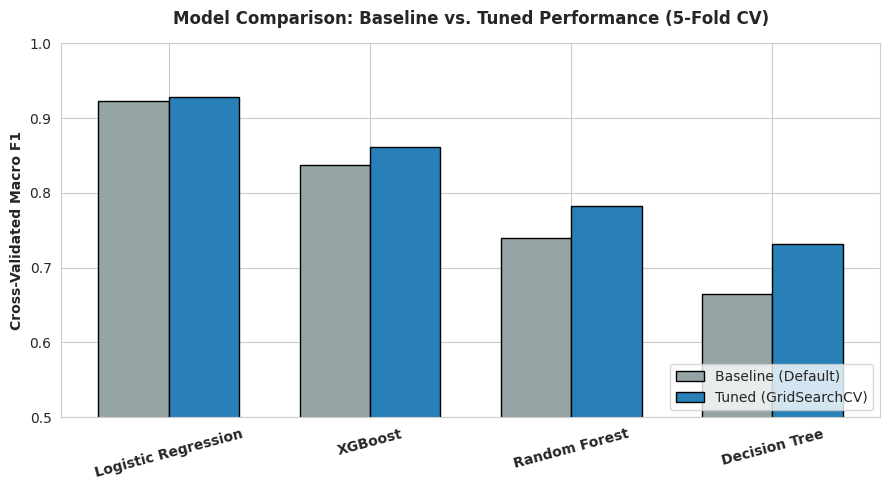

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['baseline_f1_macro'], width, label='Baseline (Default)', color='#95a5a6', edgecolor='black')
ax.bar(x + width/2, comparison_df['tuned_f1_macro'], width, label='Tuned (GridSearchCV)', color='#2980b9', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['model'], rotation=15, fontweight='bold')
ax.set_ylabel('Cross-Validated Macro F1', fontweight='bold')
ax.set_title('Model Comparison: Baseline vs. Tuned Performance (5-Fold CV)', pad=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)

plt.tight_layout()
fig.savefig(MODELS_FIG_DIR / 'model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Preliminary Test Set Diagnostic (Generalization Gap Check)

**Clinical Safety Check:** We perform a preliminary scoring against the holdout set (`X_test`) to compute the `cv_test_gap`. A large negative gap indicates severe overfitting to the training distribution[cite: 3].
*(Note: Full detailed multi-class benchmarking is deferred to Task 06).*

In [ ]:
final_models = {
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

sanity_rows = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    sanity_rows.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'cv_f1_macro (train)': comparison_df.loc[comparison_df['model'] == name, 'tuned_f1_macro'].values[0],
    })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df['cv_test_gap'] = sanity_df['cv_f1_macro (train)'] - sanity_df['test_f1_macro']
sanity_df = sanity_df.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

print("=== GENERALIZATION GAP DIAGNOSTIC ===")
sanity_df.round(4)

=== GENERALIZATION GAP DIAGNOSTIC ===


,model,test_accuracy,test_f1_macro,cv_f1_macro (train),cv_test_gap
0,Logistic Regression,0.925,0.9285,0.9288,0.0003
1,XGBoost,0.835,0.8181,0.8609,0.0428
2,Random Forest,0.790,0.7674,0.7825,0.0151
3,Decision Tree,0.730,0.7343,0.7312,-0.0031


## Section 8 — Model Serialization & Metadata Logging

We export the optimized candidate models alongside a `model_metadata.json` dictionary. This ensures an unbroken chain of custody for hyperparameter configurations to be utilized by Task 06 (Evaluation) and Task 08 (Streamlit Prototype)[cite: 3].

In [ ]:
model_filenames = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
}

metadata = {}

for name, model in final_models.items():
    filename = model_filenames[name]
    model_path = MODELS_DIR / f'{filename}.pkl'
    joblib.dump(model, model_path)

    row = comparison_df.loc[comparison_df['model'] == name].iloc[0]
    metadata[name] = {
        'file': f'{filename}.pkl',
        'best_params': tuned_df.loc[tuned_df['model'] == name, 'best_params'].values[0],
        'cv_f1_macro': round(float(row['tuned_f1_macro']), 4),
        'baseline_f1_macro': round(float(row['baseline_f1_macro']), 4),
        'random_state': RANDOM_STATE,
    }
    print(f" Saved serialized model: {model_path}")

# Export Metadata JSON
with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"\n Exported comprehensive model_metadata.json")

 Saved serialized model: ../models/logistic_regression.pkl
 Saved serialized model: ../models/decision_tree.pkl
 Saved serialized model: ../models/random_forest.pkl
 Saved serialized model: ../models/xgboost.pkl

 Exported comprehensive model_metadata.json


In [ ]:
# Optional: Save raw prediction probabilities for ensembling or dashboard usage
for name, model in final_models.items():
    filename = model_filenames[name]
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    pred_df = pd.DataFrame(y_proba, columns=[f'proba_{RISK_LABEL_MAP[i]}' for i in range(3)])
    pred_df.insert(0, 'y_true', y_test.values)
    pred_df.insert(1, 'y_pred', y_pred)

    pred_df.to_csv(PREDICTIONS_DIR / f'{filename}_test_predictions.csv', index=False)

comparison_df.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)
print(f" Saved per-model probability outputs to {PREDICTIONS_DIR.resolve()}")

 Saved per-model probability outputs to /models/predictions


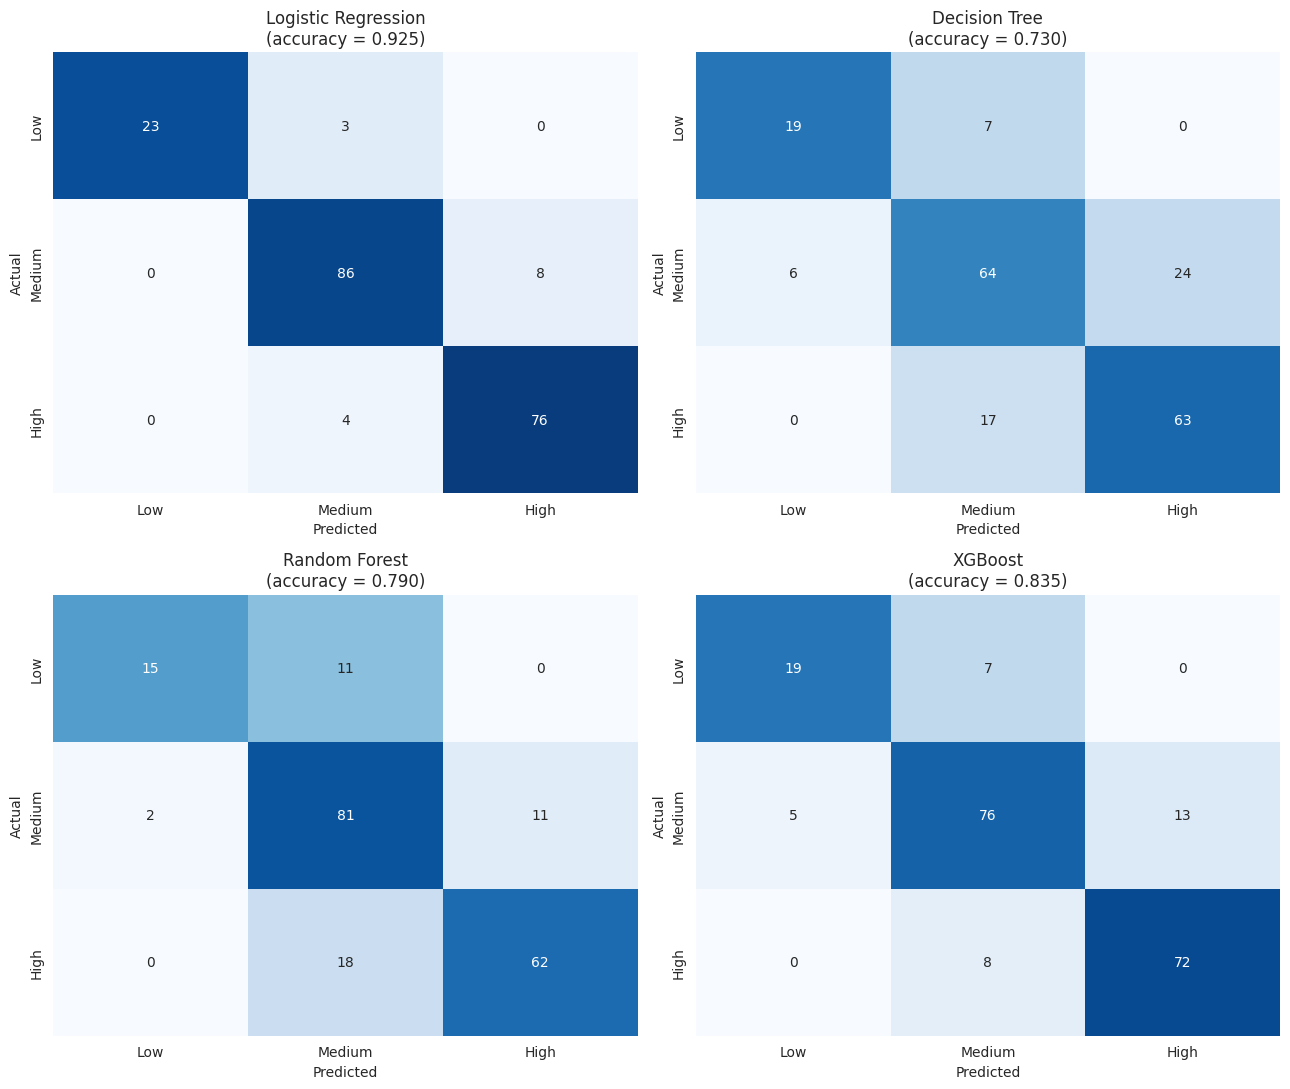

In [87]:
from sklearn.metrics import confusion_matrix

# Define CLASS_NAMES and EVAL_FIG_DIR
CLASS_NAMES = [RISK_LABEL_MAP[i] for i in sorted(RISK_LABEL_MAP.keys())]
EVAL_FIG_DIR = FIGURES_DIR / 'evaluation'
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized, annot=cm, fmt='d', cmap='Blues', cbar=False,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
        vmin=0, vmax=1
    )
    ax.set_title(f'{name}\n(accuracy = {accuracy_score(y_test, y_pred):.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
fig.savefig(f'{EVAL_FIG_DIR}/confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()